# 2. Building your flows: GaAs convergence study

Some flows have too many tasks, or tasks that run too long, to build *and*
run live in a 3h session -- the ecut/k-point convergence studies, the
relaxation, the two band structures, and the DFPT phonon calculation all
fall in this category. For those, the pattern flips:

* Instead of a `run_*.py` script you execute yourself (Notebook 1), you get
  a **`make_*.py`** script -- same idea, but the name is a reminder that
  it shows *how* the flow was constructed, not an instruction to run it
  now.
* The corresponding `flow_*/` directory has **already been run for you**,
  next to the notebook that analyzes it, ready to open with `abiopen` and
  `Robot`s.

As in Notebook 1, we'll look at each flow through the `workshop_lib.py`
function(s) it's built from (`wlib.print_source`), rather than printing
the whole standalone script -- but every section below has a matching
`make_*.py` in `../Examples/` that you're welcome to re-run yourself if you
want to reproduce or tweak a result; nothing about them is different in
kind from Notebook 1's scripts, they just build bigger flows.

**Sections below:**

* 2.1 Convergence study -- ecut and k-point convergence
* 2.2 Band structure


**Useful links:**
* [Index of Abinit input variables](https://docs.abinit.org/variables/#A)

In [1]:
from pathlib import Path
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from abipy import abilab
import abipy.flowtk as flowtk
abilab.enable_notebook()

%matplotlib inline

import workshop_lib as wlib

# 2.1 Convergence study


## 2.1.1 ecut convergence

Standalone version: 

* `make_gaas_convecut.py`.
* `plot_gaas_convecut.py`.  

Let's have a look at the functions we will use.
In a typical script that builds the flow, you would declare these functions explicitly.

In [2]:
wlib.print_source(wlib.gs_input)
wlib.print_source(wlib.build_ecut_conv_flow)
wlib.print_source(wlib.setup_manager)

### Build the flow

In [2]:
# Construct a flow where each task runs a scf calculation with different values for ecut
flow = wlib.build_ecut_conv_flow(workdir="flow_gaas_convecut")

# Print out the list of values with ecut
print(f"{len(list(flow.iflat_tasks()))} SCF tasks, ecut = "
      f"{[t.input['ecut'] for t in flow.iflat_tasks()]}")

8 SCF tasks, ecut = [10, 15, 20, 25, 30, 35, 40, 45]


Compare `wlib.gs_input`/`build_ecut_conv_flow` with `wlib.si_gs_input`/
`build_si_gs_task` from Notebook 1: same anatomy (structure, pseudos,
`AbinitInput`), just registering several SCF tasks in one `Flow` instead
of a single `Task` run synchronously. Assuming the flow has been run
(`flow_gaas_convecut/`), a `GsrRobot` collects every `GSR.nc` file into a
single `DataFrame`:


In [4]:
# Set number of processors
flow = wlib.setup_manager(flow, mpi_procs=4, omp_threads=1)


Here we actually write the files, but first we check that the flow directory doesn't actually exist.
This is not recommended for your script. The example scripts will not overwrite an existing flow directory, because it might contain precious data.
Hence, the user should remove any previous run ('rm -r flow_to_overwrite') before executing the script.

In [9]:
# Remove an existing flow directory from previus run (not recommended)
if Path(flow.workdir).exists():
    shutil.rmtree(flow.workdir)

In [10]:
# Write the flow to disk
flow.build_and_pickle_dump()

if Path(flow.workdir).exists():
    print(f'Successfully built flow: {flow.workdir}')

Successfully built flow: /Users/antonius/Documents/Workshops/2026-CEMDI/Tutorial/Notebooks/flow_gaas_convecut


### Run the flow

In [11]:
wlib.shell_command("abirun.py flow_gaas_convecut scheduler", silent=True)

When you execute this command in the shell, you should see a table that updates every 5s (or whatever time you set in your `~/.abinit/abipy/scheduler.yml` file.)
In this notebook, the scheduler is invoked but the output is suppressed. You can check the status of the workflow with the following command.

In [5]:
wlib.shell_command('abirun.py flow_gaas_convecut status')

Running on Eudora.cgocable.ca -- system Darwin -- Python 3.12.3 -- abirun-0.9.8

Work #0: <Work, node_id=1465, workdir=flow_gaas_convecut/w0>, Finalized=True 
  Finalized works are not shown. Use verbose > 0 to force output.

Work #1: <Work, node_id=1467, workdir=flow_gaas_convecut/w1>, Finalized=True 
  Finalized works are not shown. Use verbose > 0 to force output.

Work #2: <Work, node_id=1469, workdir=flow_gaas_convecut/w2>, Finalized=True 
  Finalized works are not shown. Use verbose > 0 to force output.

Work #3: <Work, node_id=1471, workdir=flow_gaas_convecut/w3>, Finalized=True 
  Finalized works are not shown. Use verbose > 0 to force output.

Work #4: <Work, node_id=1473, workdir=flow_gaas_convecut/w4>, Finalized=True 
  Finalized works are not shown. Use verbose > 0 to force output.

Work #5: <Work, node_id=1475, workdir=flow_gaas_convecut/w5>, Finalized=True 
  Finalized works are not shown. Use verbose > 0 to force output.

Work #6: <Work, node_id=1477, workdir=flow_gaas_c

If you're running the flow in the shell, you will see live updates untill the flow completes.
If you're running it throught this notebook, then you can execute the previous cell several times to see the flow is progressing, until it prints out 'all_ok reached'.

### Examine the result

Each calculation result is stored in a 'GSR.nc' file.
The example `plot_gaas_convecut` shows you how to plot it from a list of files.

In [5]:
from abipy.tools.plotting import ConvergenceAnalyzer

wlib.print_source(wlib.get_gsr_files)
wlib.print_source(wlib.plot_ecut_conv)

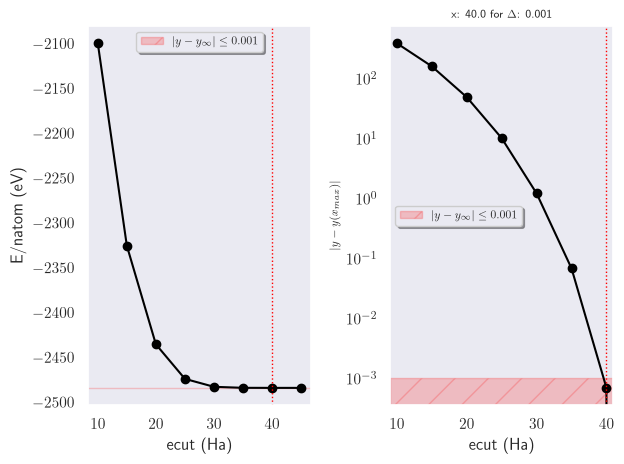

In [7]:
fig = wlib.plot_ecut_conv(workdir="flow_gaas_convecut", figname=None)

We see here that we need a rather large value of ecut to reach 10^-3 convergence. 
Could we get away with a smaller value?

Another way to do this is to use a "robot" to gather the files from a flow directory into a pandas dataframe...in case you liked pandas dataframes.

In [14]:
# Extract results with a table
with abilab.GsrRobot.from_dir("flow_gaas_convecut") as robot:
    table = robot.get_dataframe()

ecut_Ha = table.sort_values("ecut")["ecut"].tolist()
energy_per_atom_eV = (table.sort_values("ecut")["energy"] / len(wlib.gaas_structure())).tolist()

# Display the table
table[["ecut", "energy", "pressure"]].sort_values("ecut")

,ecut,energy,pressure
w0/t0/outdata/out_GSR.nc,10.0,-4198.999889,-2591.450882
w1/t0/outdata/out_GSR.nc,15.0,-4650.702148,-2204.965314
w2/t0/outdata/out_GSR.nc,20.0,-4870.650639,-1192.070490
w3/t0/outdata/out_GSR.nc,25.0,-4947.719585,-412.246355
w4/t0/outdata/out_GSR.nc,30.0,-4965.441205,-79.453945
w5/t0/outdata/out_GSR.nc,35.0,-4967.719365,-7.463508
w6/t0/outdata/out_GSR.nc,40.0,-4967.853620,-0.221030
w7/t0/outdata/out_GSR.nc,45.0,-4967.854997,-0.103363


More examples are found in the abipy_books

## 2.1.2 k-point convergence

Standalone version: 

* `make_gaas_convkpt.py`.
* `plot_gaas_convkpt.py`.    

Same idea, but now `ecut` is fixed and we vary the k-mesh via
`set_autokmesh(nk)`, which generates an increasingly dense homogeneous
mesh. `gs_input` is the same function shown above.


In [3]:
wlib.print_source(wlib.build_kpt_conv_flow)

### Build and run the flow

Standalone version: `../Examples/make_gaas_convkpt.py`. From a terminal,
in `Examples/` (so the resulting `flow_*/` directory lands next to the
script, matching the paths used below):

```
cd ../Examples
python make_gaas_convkpt.py
abirun.py flow_gaas_convkpt scheduler
```

This has already been run for you (`flow_gaas_convkpt/`, next to this
notebook) -- the analysis below reads directly from it.


In [4]:
# Construct a flow where each task runs a scf calculation with different values for ecut
flow = wlib.build_kpt_conv_flow(workdir="flow_gaas_convkpt", nk_list=(1, 2, 4, 6, 8, 10), ecut=12)

print(f"{len(list(flow.iflat_tasks()))} SCF tasks, ngkpt = "
      f"{[t.input['ngkpt'] for t in flow.iflat_tasks()]}")

6 SCF tasks, ngkpt = [array([1, 1, 1]), array([2, 2, 2]), array([4, 4, 4]), array([6, 6, 6]), array([8, 8, 8]), array([10, 10, 10])]


In [5]:
# Set number of processors
flow = wlib.setup_manager(flow, mpi_procs=4, omp_threads=1)

Write the files, but first check that the flow directory doesn't already exist and remove any previous run.
This is not recommended for your script. The example scripts will not overwrite an existing flow directory, because it might contain precious data.
Hence, the user should remove any previous run ('rm -r flow_to_overwrite') before executing the script.

In [6]:
# Remove an existing flow directory from previus run (not recommended)
if Path(flow.workdir).exists():
    shutil.rmtree(flow.workdir)

In [7]:
# Write the flow to disk
flow.build_and_pickle_dump()

if Path(flow.workdir).exists():
    print(f'Successfully built flow: {flow.workdir}')

Successfully built flow: /Users/Antonius/Documents/Workshops/2026-CEMDI/Tutorial/Notebooks/flow_gaas_convkpt


### Run the flow

In [8]:
wlib.shell_command("abirun.py flow_gaas_convkpt scheduler", silent=True)

In [10]:
wlib.shell_command('abirun.py flow_gaas_convkpt status')

Running on Beatrix -- system Darwin -- Python 3.12.8 -- abirun-1.0.0

Work #0: <Work, node_id=3648, workdir=flow_gaas_convkpt/w0>, Finalized=True 
  Finalized works are not shown. Use verbose > 0 to force output.

Work #1: <Work, node_id=3650, workdir=flow_gaas_convkpt/w1>, Finalized=True 
  Finalized works are not shown. Use verbose > 0 to force output.

Work #2: <Work, node_id=3652, workdir=flow_gaas_convkpt/w2>, Finalized=True 
  Finalized works are not shown. Use verbose > 0 to force output.

Work #3: <Work, node_id=3654, workdir=flow_gaas_convkpt/w3>, Finalized=True 
  Finalized works are not shown. Use verbose > 0 to force output.

Work #4: <Work, node_id=3656, workdir=flow_gaas_convkpt/w4>, Finalized=True 
  Finalized works are not shown. Use verbose > 0 to force output.

Work #5: <Work, node_id=3658, workdir=flow_gaas_convkpt/w5>, Finalized=True 
  Finalized works are not shown. Use verbose > 0 to force output.

all_ok reached



### Examine the result

The example `plot_gaas_convkpt.py` shows you how to plot the k-point
convergence from a flow directory.


In [4]:
wlib.print_source(wlib.get_gsr_files)
wlib.print_source(wlib.plot_kpt_conv)

Now let's look at the result.

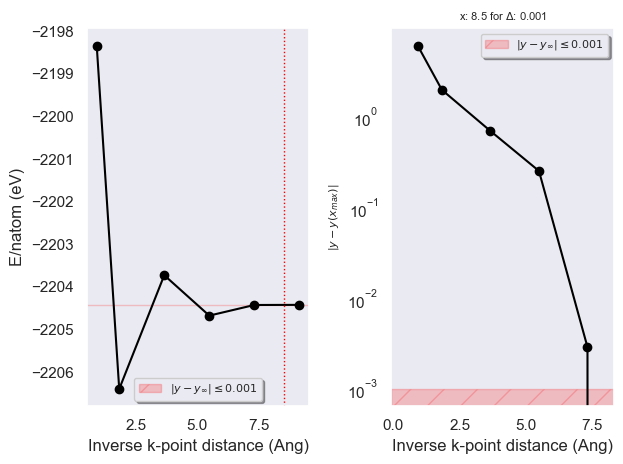

In [11]:
fig = wlib.plot_kpt_conv(workdir="flow_gaas_convkpt", figname='', show=True)

Well this is not as good as expected! We were aiming for a 10^-3 convergence. Actually, our value of ecut was too small!

> **Exercise.** Redo the k-point convergence study with a larger ecut value, the plot the convergence result.

To see why we get the behaviour, we should plot the band structure.

# 2.2 Band structure

Standalone version:

* `make_gaas_ebands.py`.
* `plot_gaas_ebands.py`.



In [11]:
wlib.print_source(wlib.build_gaas_ebands_flow)

In [16]:
flow = wlib.build_gaas_ebands_flow(workdir="flow_gaas_ebands")

In [17]:
# Set number of processors
flow = wlib.setup_manager(flow, mpi_procs=4, omp_threads=1)

Write the files, but first check that the flow directory doesn't already exist and remove any previous run.
This is not recommended for your script. The example scripts will not overwrite an existing flow directory, because it might contain precious data.
Hence, the user should remove any previous run ('rm -r flow_to_overwrite') before executing the script.

In [18]:
# Remove an existing flow directory from previus run (not recommended)
if Path(flow.workdir).exists():
    shutil.rmtree(flow.workdir)

In [19]:
# Write the flow to disk
flow.build_and_pickle_dump()

if Path(flow.workdir).exists():
    print(f'Successfully built flow: {flow.workdir}')

Successfully built flow: /Users/antonius/Documents/Workshops/2026-CEMDI/Tutorial/Notebooks/flow_gaas_ebands


In [20]:
wlib.shell_command("abirun.py flow_gaas_ebands scheduler", silent=True)

In [3]:
# Run this cell several times to see progress
wlib.shell_command('abirun.py flow_gaas_ebands status')

Running on Eudora.cgocable.ca -- system Darwin -- Python 3.12.3 -- abirun-0.9.8

Work #0: <BandStructureWork, node_id=1584, workdir=flow_gaas_ebands/w0>, Finalized=True 
  Finalized works are not shown. Use verbose > 0 to force output.

all_ok reached



Plot the band structurewlib.print_source(wlib.build_gaas_ebands_flow)

In [2]:
wlib.print_source(wlib.plot_ebands)

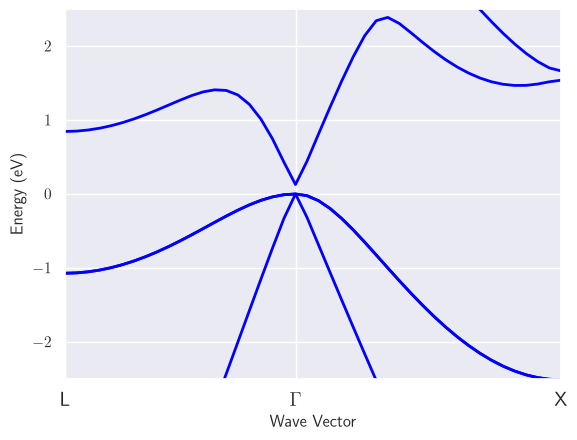

In [8]:
# Display resulting figure
fig = wlib.plot_ebands('flow_gaas_ebands', figname='', ylims=(-2.5,2.5), show=True)

In [ ]:
Does it look okay?

# Exercise

Redo the k-points convergence with a larger value of `ecut=40`.
You will find that the k-points convergence is actually sensitive to the value of `ecut`.
To see why, try plotting the band structure with a lower value of `ecut=12`.



# Next
Continue with [`3-Relaxation.ipynb`](3-Relaxation.ipynb).